In [40]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Random seed set to 42")

PyTorch version: 2.13.0+cpu
Random seed set to 42


In [41]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

In [42]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [43]:
import os

print("Files in Day 11:")
print(os.listdir("../Day 11"))

Files in Day 11:
['deep_learning_baseline.ipynb', 'Loan_default.csv', 'README.md', 'requirements.txt']


In [44]:
df = pd.read_csv("../Day 11/Loan_default.csv")

In [45]:
print("Target column values:")
print(df["Default"].value_counts())

print("\nTarget data type:")
print(df["Default"].dtype)

Target column values:
Default
0    225694
1     29653
Name: count, dtype: int64

Target data type:
int64


In [46]:
X = df.drop(columns=["Default"])
y = df["Default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (255347, 17)
y shape: (255347,)


In [47]:
if "LoanID" in X.columns:
    X = X.drop(columns=["LoanID"])

print("X shape after removing LoanID:", X.shape)

X shape after removing LoanID: (255347, 16)


In [48]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)
print("\nData types:")
print(X.dtypes.value_counts())

X shape after encoding: (255347, 24)

Data types:
bool       15
int64       7
float64     2
Name: count, dtype: int64


In [49]:
X = X.astype(np.float32)

print("X data type:", X.dtypes.unique())
print("X shape:", X.shape)

X data type: [dtype('float32')]
X shape: (255347, 24)


In [50]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [51]:
X = X.fillna(X.median(numeric_only=True))


In [52]:
print("Missing values after cleaning:", X.isnull().sum().sum())

Missing values after cleaning: 0


In [53]:
y = y.astype(int)

print("Target classes:", sorted(y.unique()))
print("Target distribution:")
print(y.value_counts())

Target classes: [np.int64(0), np.int64(1)]
Target distribution:
Default
0    225694
1     29653
Name: count, dtype: int64


In [54]:
indices = np.arange(len(X))

np.random.seed(SEED)
np.random.shuffle(indices)

split_index = int(0.80 * len(indices))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (204277, 24)
X_test : (51070, 24)
y_train: (204277,)
y_test : (51070,)


In [55]:
train_mean = X_train.mean()
train_std = X_train.std()

train_std = train_std.replace(0, 1)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Feature scaling completed!")

Feature scaling completed!


In [56]:
X_train_tensor = torch.tensor(
    X_train.values.copy(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test.values.copy(),
    dtype=torch.float32
)

print("X_train tensor:", X_train_tensor.shape)
print("X_test tensor :", X_test_tensor.shape)
print("X tensor dtype:", X_train_tensor.dtype)

X_train tensor: torch.Size([204277, 24])
X_test tensor : torch.Size([51070, 24])
X tensor dtype: torch.float32


In [57]:
y_train_tensor = torch.tensor(
    y_train.values.copy(),
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test.values.copy(),
    dtype=torch.long
)

print("y_train tensor:", y_train_tensor.shape)
print("y_test tensor :", y_test_tensor.shape)
print("y tensor dtype:", y_train_tensor.dtype)

y_train tensor: torch.Size([204277])
y_test tensor : torch.Size([51070])
y tensor dtype: torch.int64


In [58]:
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_test :", X_test_tensor.shape)
print("y_test :", y_test_tensor.shape)

X_train: torch.Size([204277, 24])
y_train: torch.Size([204277])
X_test : torch.Size([51070, 24])
y_test : torch.Size([51070])


In [59]:
input_size = X_train_tensor.shape[1]
output_size = len(torch.unique(y_train_tensor))

print("Input size:", input_size)
print("Output size:", output_size)

Input size: 24
Output size: 2


In [60]:
class LoanDefaultMLP(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_layer = nn.Linear(input_size, 64)

        self.hidden_layer = nn.Linear(64, 32)

        self.relu = nn.ReLU()

        self.output_layer = nn.Linear(32, output_size)

    def forward(self, x):

        x = self.input_layer(x)

        x = self.relu(x)

        x = self.hidden_layer(x)

        x = self.relu(x)

        x = self.output_layer(x)

        return x


model = LoanDefaultMLP(
    input_size,
    output_size
)

print(model)

LoanDefaultMLP(
  (input_layer): Linear(in_features=24, out_features=64, bias=True)
  (hidden_layer): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)


### ReLU Activation

ReLU (Rectified Linear Unit) is defined as:

f(x) = max(0, x)

For positive values, ReLU returns x, while for negative values it returns 0.

ReLU introduces non-linearity into the neural network and helps reduce the vanishing-gradient problem compared with sigmoid activations in deep networks because its derivative is 1 for positive inputs.

In [61]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [62]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [63]:
epochs = 20

loss_history = []

for epoch in range(epochs):

    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_tensor)

    # Calculate loss
    loss = criterion(
        outputs,
        y_train_tensor
    )

    # Backpropagation
    loss.backward()

    # Update model weights
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {loss.item():.4f}"
    )

Epoch [1/20] Loss: 0.7557
Epoch [2/20] Loss: 0.7387
Epoch [3/20] Loss: 0.7225
Epoch [4/20] Loss: 0.7069
Epoch [5/20] Loss: 0.6921
Epoch [6/20] Loss: 0.6778
Epoch [7/20] Loss: 0.6641
Epoch [8/20] Loss: 0.6508
Epoch [9/20] Loss: 0.6378
Epoch [10/20] Loss: 0.6253
Epoch [11/20] Loss: 0.6130
Epoch [12/20] Loss: 0.6009
Epoch [13/20] Loss: 0.5891
Epoch [14/20] Loss: 0.5774
Epoch [15/20] Loss: 0.5659
Epoch [16/20] Loss: 0.5546
Epoch [17/20] Loss: 0.5435
Epoch [18/20] Loss: 0.5325
Epoch [19/20] Loss: 0.5217
Epoch [20/20] Loss: 0.5111


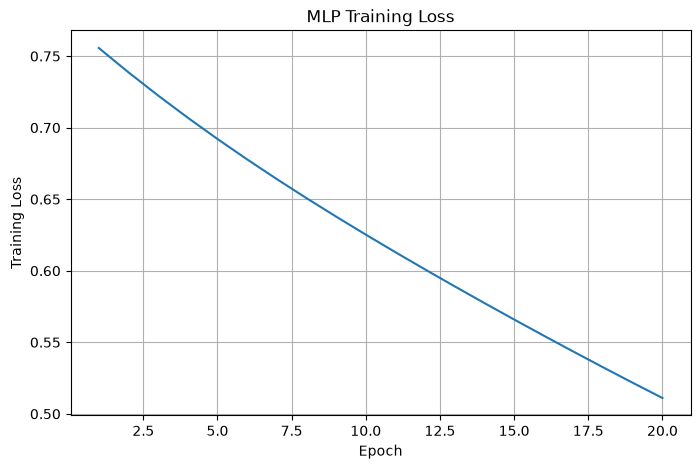

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss")

plt.grid(True)
plt.show()

In [65]:
model.eval()

with torch.no_grad():

    test_outputs = model(X_test_tensor)

    predictions = torch.argmax(
        test_outputs,
        dim=1
    )

accuracy = (
    predictions == y_test_tensor
).float().mean()

print(
    f"Test Accuracy: {accuracy.item() * 100:.2f}%"
)

Test Accuracy: 88.57%


In [66]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 204277
Validation dataset size: 51070


In [67]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 3192
Validation batches: 798


In [68]:
X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)
print("X dtype:", X_batch.dtype)
print("y dtype:", y_batch.dtype)

X batch shape: torch.Size([64, 24])
y batch shape: torch.Size([64])
X dtype: torch.float32
y dtype: torch.int64


In [69]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Adam optimizer ready")

Adam optimizer ready


In [70]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [71]:
train_losses = []
val_losses = []

num_epochs = 25

for epoch in range(num_epochs):

    # Training
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)

    # Validation
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

Epoch [1/25] Train Loss: 0.3197 Val Loss: 0.3143
Epoch [2/25] Train Loss: 0.3147 Val Loss: 0.3129
Epoch [3/25] Train Loss: 0.3134 Val Loss: 0.3137
Epoch [4/25] Train Loss: 0.3129 Val Loss: 0.3118
Epoch [5/25] Train Loss: 0.3123 Val Loss: 0.3119
Epoch [6/25] Train Loss: 0.3118 Val Loss: 0.3123
Epoch [7/25] Train Loss: 0.3113 Val Loss: 0.3127
Epoch [8/25] Train Loss: 0.3110 Val Loss: 0.3129
Epoch [9/25] Train Loss: 0.3106 Val Loss: 0.3130
Epoch [10/25] Train Loss: 0.3103 Val Loss: 0.3136
Epoch [11/25] Train Loss: 0.3097 Val Loss: 0.3129
Epoch [12/25] Train Loss: 0.3094 Val Loss: 0.3138
Epoch [13/25] Train Loss: 0.3090 Val Loss: 0.3153
Epoch [14/25] Train Loss: 0.3087 Val Loss: 0.3144
Epoch [15/25] Train Loss: 0.3083 Val Loss: 0.3141
Epoch [16/25] Train Loss: 0.3079 Val Loss: 0.3141
Epoch [17/25] Train Loss: 0.3078 Val Loss: 0.3150
Epoch [18/25] Train Loss: 0.3074 Val Loss: 0.3151
Epoch [19/25] Train Loss: 0.3070 Val Loss: 0.3156
Epoch [20/25] Train Loss: 0.3066 Val Loss: 0.3149
Epoch [21

In [72]:
print("Number of training loss values:", len(train_losses))
print("Number of validation loss values:", len(val_losses))

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])

Number of training loss values: 25
Number of validation loss values: 25
Final Training Loss: 0.3053639659046529
Final Validation Loss: 0.3170591262087487


In [73]:
best_val_loss = min(val_losses)
best_epoch = val_losses.index(best_val_loss) + 1

print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Epoch: {best_epoch}")

Best Validation Loss: 0.3118
Best Epoch: 4


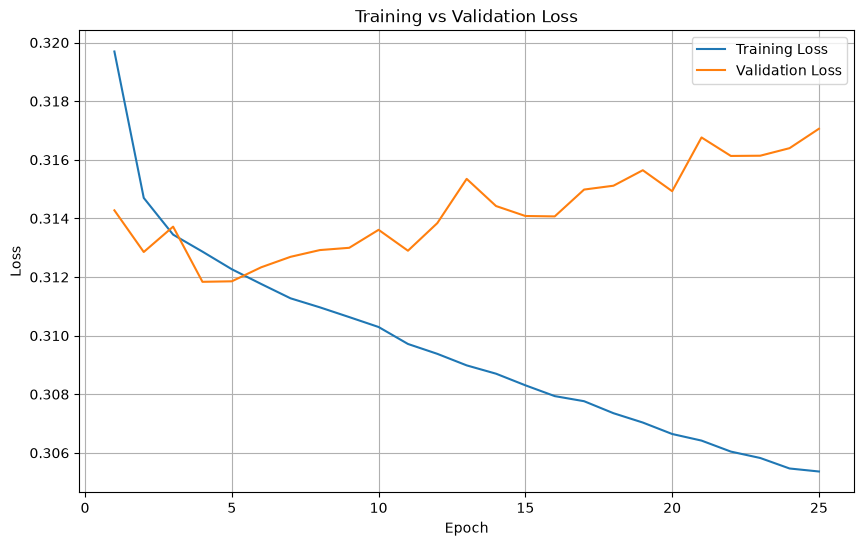

In [74]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [75]:
print("========== DAY 12 FINAL CHECK ==========")
print("Batch size: 64")
print("Training shuffle: True")
print("Validation shuffle: False")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Epochs:", len(train_losses))
print("Training loss points:", len(train_losses))
print("Validation loss points:", len(val_losses))
print("Best validation loss:", best_val_loss)
print("Best epoch:", best_epoch)

========== DAY 12 FINAL CHECK ==========
Batch size: 64
Training shuffle: True
Validation shuffle: False
Optimizer: Adam
Learning rate: 0.001
Epochs: 25
Training loss points: 25
Validation loss points: 25
Best validation loss: 0.31183627004125963
Best epoch: 4


In [76]:
print("========== TRAINING SUMMARY ==========")
print(f"Initial Training Loss: {train_losses[0]:.4f}")
print(f"Final Training Loss:   {train_losses[-1]:.4f}")
print(f"Initial Validation Loss: {val_losses[0]:.4f}")
print(f"Final Validation Loss:   {val_losses[-1]:.4f}")
print(f"Best Validation Loss:    {best_val_loss:.4f}")
print(f"Best Epoch:              {best_epoch}")

========== TRAINING SUMMARY ==========
Initial Training Loss: 0.3197
Final Training Loss:   0.3054
Initial Validation Loss: 0.3143
Final Validation Loss:   0.3171
Best Validation Loss:    0.3118
Best Epoch:              4
